# **心臟疾病辨識單元(三)：電腦真的有高視力還能一眼看出你有沒有病！**



# 0.先收錄一些會用到的公式和函式吧！

In [1]:
#@title
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import itertools
#from sklearn.preprocessing import LabelEncoder
from keras.models import Model, Sequential
from keras.layers import Conv1D, GlobalAveragePooling1D, MaxPooling1D
from keras.layers import Activation, Dense, Dropout, Input, Embedding, Flatten
from keras.callbacks import CSVLogger
from tensorflow.keras.optimizers import RMSprop,Adam
#from keras.preprocessing.text import Tokenizer
#from keras.preprocessing import sequence
#from keras.utils import to_categorical
#from keras.callbacks import EarlyStopping
from ast import literal_eval
from keras.utils.np_utils import to_categorical
import matplotlib.pyplot as plt
from keras.layers import LeakyReLU
from keras.layers import BatchNormalization

# 1.先將上個單元用的心電訊號丟進程式庫吧！





In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))


In [ ]:
#確認是否能夠成功讀取檔案
df = pd.read_csv('CNN_心電訊號.csv',delimiter=',',converters=dict(v2 = literal_eval ))
df.info()

# 2.將心電訊號調整成固定格式吧！(複習7.1單元的補零技巧)

In [ ]:
X = df.iloc[:,1:].values
lengthOfData = 2900
numberOfData = 60
tempZ = np.zeros(shape=(numberOfData,lengthOfData))

tempX = []
errornum = 0
z=0

for a in X:
    amountOfPadding = lengthOfData - len(a[0])

    if len(a[0]) < lengthOfData :
        
        #print('Start Padding')
        tempX = np.pad(a[0], (0,amountOfPadding), 'constant', constant_values=(0,0))
        #print('tempX=')
        #print(tempX)
        tempZ[z] = tempX
        #print('round')
        z = z + 1         
    else:
        #print('error')
        errornum = errornum + 1
        tempX = np.pad(a[0], (0,0), 'constant', constant_values=(0,0))
        #print('tempX=')
        #print(tempX)
        
        #tempZ[z] = tempX
        z = z + 1


print('error=',errornum)

# 3.方便起見，將資料以7:3的比例分成訓練集和測試集吧！

*   如果大家有打開心電訊號的檔案，會發現第二欄才是心電訊號，第一欄是這串心電訊號的類別(正常 or 心律不整)
*   標記0為正常心電訊號；1則為心律不整

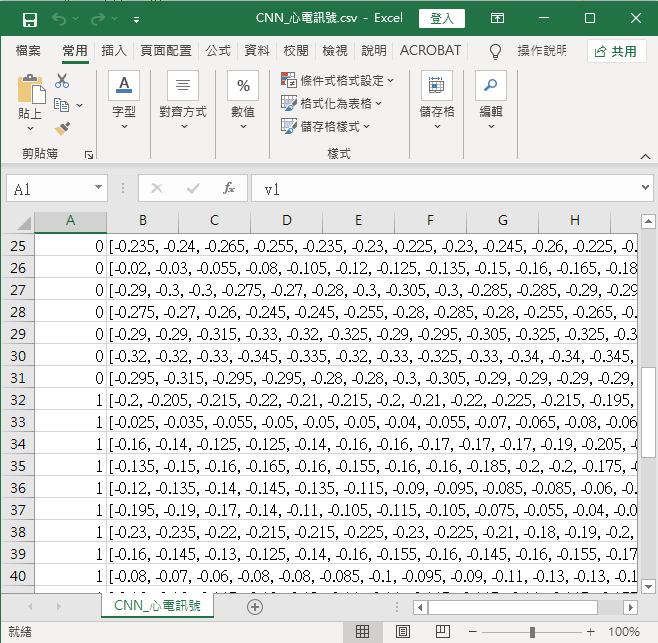

In [5]:
#將資料分類，並把資料分成測試集和訓練集，最後整理成CNN模型方便處理的資料格式！
Y = df.iloc[:,:1].values
Y = to_categorical(Y,num_classes=2) #資料有正常心電訊號、心律不整心電訊號兩類

X_train,X_test,Y_train,Y_test = train_test_split(tempZ,Y,test_size=0.3) #設定資料測試集的比例為0.3，訓練集則固定為0.7，這僅是通常的設定並非規定。
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1)) 
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

#4. 開始一層一層搭建課程中學習過的CNN模型吧！

*   大家如果仔細看會發現這個模型比起前一小結示範模型要複雜許多，這其實其實是鐵克透過反覆測試不同的架構與堆疊方式，嘗試出的一種模型啦！
*   更多的層數可能能讓模型的預測更準確，卻也可能因此讓運算負擔增加，拖緩運算速度。模型的建置沒有最好，只有相對適合唷！

In [ ]:
print('Start CNN')
model = Sequential()
model.add(Conv1D(filters=101, kernel_size=81, activation='linear', input_shape=(lengthOfData, 1))) #建立101組卷積核來取得101個特徵圖片
model.add(LeakyReLU(alpha=.001)) #激活函式來提升CNN的複雜度
model.add(Conv1D(filters=101, kernel_size=81, activation='linear')) #再次將特徵資料以101組卷積核來取得更多元的特徵圖片
model.add(LeakyReLU(alpha=.001)) #激活函式來提升CNN的複雜度
model.add(MaxPooling1D(3)) #最大值池化來精煉資料
model.add(Dropout(0.5))  #避免過度依賴特定資料而使用
model.add(Conv1D(filters=201, kernel_size=81, activation='linear')) #再次將特徵資料以201組卷積核來取得更多元的特徵圖片
model.add(LeakyReLU(alpha=.001)) #激活函式來提升CNN的複雜度
model.add(GlobalAveragePooling1D()) #平均值池化來精煉資料
model.add(Dropout(0.5)) #避免過度依賴特定資料而使用
model.add(Dense(2, activation='softmax')) #全連接層來幫資料收斂成最後兩個分類吧！
print(model.summary()) #秀出你的模型會長什麼樣子吧！


model.compile(loss='categorical_crossentropy',optimizer=Adam(learning_rate=0.01, beta_1=0.9, beta_2=0.999, epsilon=None, decay=0.001, amsgrad=False),metrics=['accuracy']) #幫模型選擇訓練的損失函數與優化器！


# 5. 用切割好的訓練集的資料，來好好磨練你的CNN模型吧！


*   訓練流程的設計還可以調整batch size和 epochs
*   batch size :　在一次訓練中要提供多少筆資料
*   epochs : 總共要給模型幾次訓練



In [ ]:
#第一次試著用batch size為10, epochs為20的參數，給CNN模型來一場魔鬼訓練吧！
#完成這樣參數的訓練約略需要10分鐘，請同學稍安勿躁。

history = model.fit(X_train,Y_train,batch_size=10,epochs=20,validation_split=0.3)

model.save('CNN_MIT.h5')


plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()



#6. 用切割好的測試集的資料，來看看你的CNN模型夠不夠給力吧！

In [ ]:
accr = model.evaluate(X_test,Y_test)
argmax = np.argmax(model.predict(X_test), axis=1)

print("\n測試集裡面的心電訊號經過CNN辨識結果從第一筆依序為", argmax)
print("其中的判斷，0為正常狀況心電訊號；1為心律不整心電訊號")
print("測試的整體準確度為", accr[1]*100,"%")

調整check_index來觀看每一筆測試集的波形圖吧！

In [ ]:
#用肉眼來看看CNN展現的神蹟吧~~
#0為正常狀況心電訊號；1為心律不整心電訊號

check_index = 1 #從1改到18，肉眼查看心電訊號是不是真如模型辨識的一樣吧！


#稍微設定一下畫布資訊！
fig = go.Figure()
fig.add_trace(go.Scatter(
    y=np.transpose(X_test[check_index-1])[0], #取用其中一筆心電訊號
    mode='lines',
    name='Original Plot',
)
)
fig.update_layout(
    title="其中一筆測試集的心電訊號",
    font=dict(
        family="Courier New, monospace",
        size=20,
        color="RebeccaPurple"
    )
)
fig.show()


# 章節總結：


---


我想做到這邊的大家應該心中會有點不太踏實，存在許多疑點。像是卷積核為什麼寬度要設為81，數量又為什麼是101個？還有為什麼優化器還會有這麼多沒看過的參數？但其實多數的研究員都有一個共識是「多做實驗，找到最佳值」。雖然這個模型能夠順利地判別這次提供的資料，但在其他場合或情境可就不一定了！在未來如果有機會，也試著自己打造一個能解決特定問題，屬於自己的人工智慧CNN模型吧！

# 恭喜完成本章節課程



> 有需要的同學可以使用密碼搭配書籍網站取得課程證書

> 證書密碼：「yutechAI4」！